# Neural Net Torch Implementation

This notebook:

1. Generates a labelled guasssian distribution in a torch tensor
2. Defines a torch MLP
3. Runs a training loop on the torch MLP
4. Plots the decesion boundary generated by the MLP by using a grid like structure

This a project is part of a series of projects used to build my foundational knowledge of ML to help with mech interp.

In [1]:
import torch
from torch import nn
from jaxtyping import Float

In [2]:
def make_gaussian_data(mean: tuple[float, float], count: int, std: float, label: int) -> Float[torch.Tensor, "count 3"]:
    mean_tensor = torch.tensor(mean)
    gaussian = torch.randn(count, 2) * std + mean_tensor
    labels = torch.full((count, 1), label)
    return torch.cat([gaussian, labels], dim=1)

cluster_1 = make_gaussian_data((2, 2), 200, 1.0, 0)
cluster_2 = make_gaussian_data((-2, -2), 200, 1.0, 1)

data = torch.cat([cluster_1, cluster_2], dim=0)

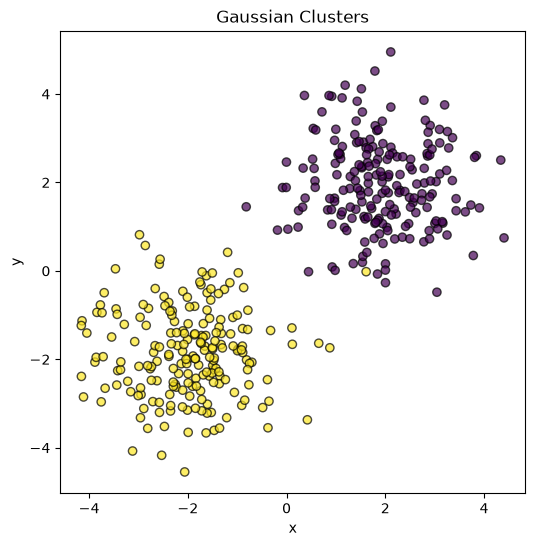

In [3]:
import matplotlib.pyplot as plt

data_np = data.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], c=data_np[:, 2], alpha=0.7, edgecolors="k")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Clusters")
plt.show()

In [4]:
class MLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    
model = MLP()
output = model(torch.randn(1,2))
output

tensor([[0.6737, 0.5676]], grad_fn=<AddmmBackward0>)

In [5]:
def train(model, X, y, criterion, epochs=1000, lr=0.1):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimiser.zero_grad()
        output = model(X)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(output, y)
        loss.backward()
        optimiser.step()
        if epoch % 20 == 0:
            print(loss.item())

X = data[:, :2]
y = data[:, 2].long()
criterion = nn.CrossEntropyLoss()
train(model, X, y, criterion)

0.4438778758049011
0.0456145778298378
0.028373489156365395
0.02223612368106842
0.01913118176162243
0.0172797292470932
0.016059884801506996
0.015197361819446087
0.014560678973793983
0.014074745588004589
0.01368878036737442
0.013374652713537216
0.013113888911902905
0.012893625535070896
0.012704775668680668
0.012540776282548904
0.012396634556353092
0.012268693186342716
0.012154008261859417
0.012050461024045944
0.011956180445849895
0.011869765818119049
0.01179022528231144
0.011716414242982864
0.011647704057395458
0.011583440005779266
0.011523089371621609
0.011466133408248425
0.011412347666919231
0.011361374519765377
0.01131289079785347
0.01126671303063631
0.011222603730857372
0.011180375702679157
0.011139851063489914
0.011100895702838898
0.011063515208661556
0.011027556844055653
0.010992794297635555
0.01095917820930481
0.010926696471869946
0.01089523360133171
0.010864697396755219
0.010835123248398304
0.01080636028200388
0.01077840942889452
0.010751238092780113
0.010724811814725399
0.010699

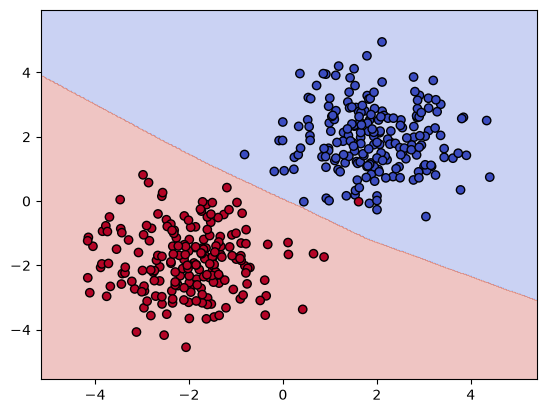

tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [7]:
def decision_boundary(model, steps):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    x_vals = torch.linspace(x_min, x_max, steps)
    y_vals = torch.linspace(y_min, y_max, steps)
    xx, yy = torch.meshgrid(x_vals, y_vals, indexing='xy')
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)

    model.eval()
    with torch.no_grad():
        preds = model(grid).argmax(dim=1) 

    preds = preds.reshape(xx.shape)

    plt.contourf(xx.numpy(), yy.numpy(), preds.numpy(), alpha=0.3, cmap='coolwarm')
    plt.scatter(data[:, 0], data[:, 1], c=data_np[:, 2], cmap='coolwarm', edgecolors='k')
    plt.show()

    return preds


decision_boundary(model, 400)